Imports


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob #used to pattern match files
from scipy.io import loadmat

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, RBF, RationalQuadratic
from sklearn.metrics import mean_squared_error

Functions for processing data/creating figures


In [ ]:
def create_timeseries(df, x, y, title, filename=None):
    # function for creating and saving a timeseries
    plt.figure(figsize=(10,10))
    sns.lineplot(data=df, x=x, y=y, label='Enso Variability', color='blue')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.gca().invert_xaxis()
    plt.title(title)
    plt.tight_layout()

    if filename is not None:
        plt.savefig(f"figures/{filename}", dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()


def bin_to_nyr(df, value_col, bin_size):

    df = df[["year_bp", value_col]].dropna().copy()

    # create 50-year bins
    df["year_bp_50"] = (df["year_bp"] // bin_size) * bin_size

    # average within bins
    df = df.groupby("year_bp_50", as_index=False)[value_col].mean()

    # rename for consistency
    df = df.rename(columns={
        "year_bp_50": "year_bp",
        value_col: "normalized_enso_var"
    })

    # re-normalize AFTER binning (important)
    df["normalized_enso_var"] = (
        (df["normalized_enso_var"] - df["normalized_enso_var"].mean()) /
        df["normalized_enso_var"].std()
    )

    return df



# cleaning the data

In [ ]:
# variables that can be changed to influence the reconstruction
rolling_std = 50
min_periods = int(0.5 * rolling_std)
bin_size = 50

data 1

XRF of laguna Pallcacocha

age is yr bp

is a proxy based on lanimated sedimenrary seque

has Pc1 (that is flipped with more negative being stronger)

not yet variability

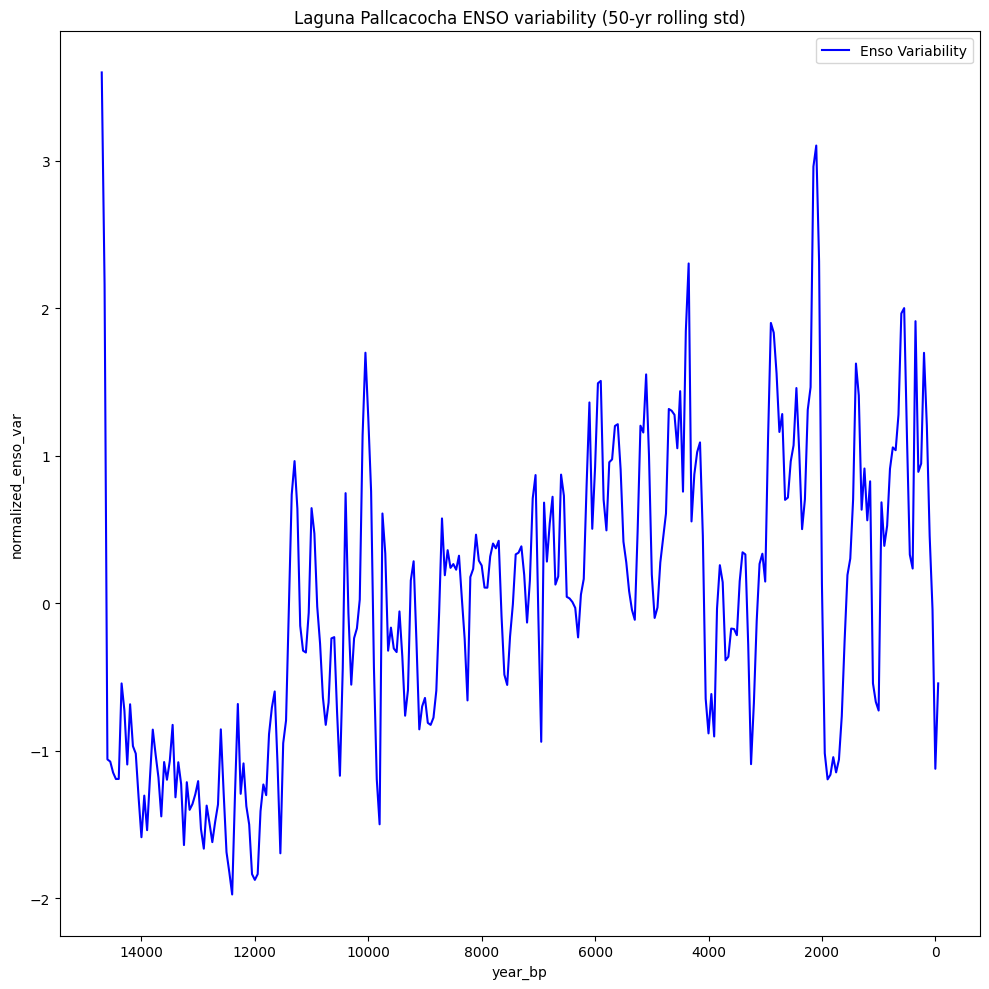

In [ ]:
# first calculate the rollin stdev
# next normalize

df1 = pd.read_csv("useable_form_data/XRF_PC1_data.tsv", sep = '\t')

# convert to year_bp
df1["year_bp"] = df1["Age"]

# average duplicate years
df1 = df1.groupby("year_bp", as_index=False)["PC1"].mean()

# # invert signal so higher = stronger ENSO-related activity
df1["PC1"] = -df1["PC1"]

# smooth event intensity at 50-year scale
# detrend first
df1["trend"] = df1["PC1"].rolling(
    window=300,
    center=True,
    min_periods=100
).mean()

df1["residual"] = df1["PC1"] - df1["trend"]

# THEN compute variability
df1["enso_var"] = df1["residual"].rolling(
    window=rolling_std,
    center=True,
    min_periods=min_periods
).std()

df1["normalized_enso_var"] = (
    (df1["enso_var"] - df1["enso_var"].mean()) / df1["enso_var"].std()
)

df1_final = bin_to_nyr(df1, "normalized_enso_var", bin_size)

create_timeseries(df1_final, "year_bp", "normalized_enso_var", "Laguna Pallcacocha ENSO variability (50-yr rolling std)")


data 3

Reconstructed SST-NINO3.4 anomalies for the years 850 to 1981

is only data starting from year 850 to present

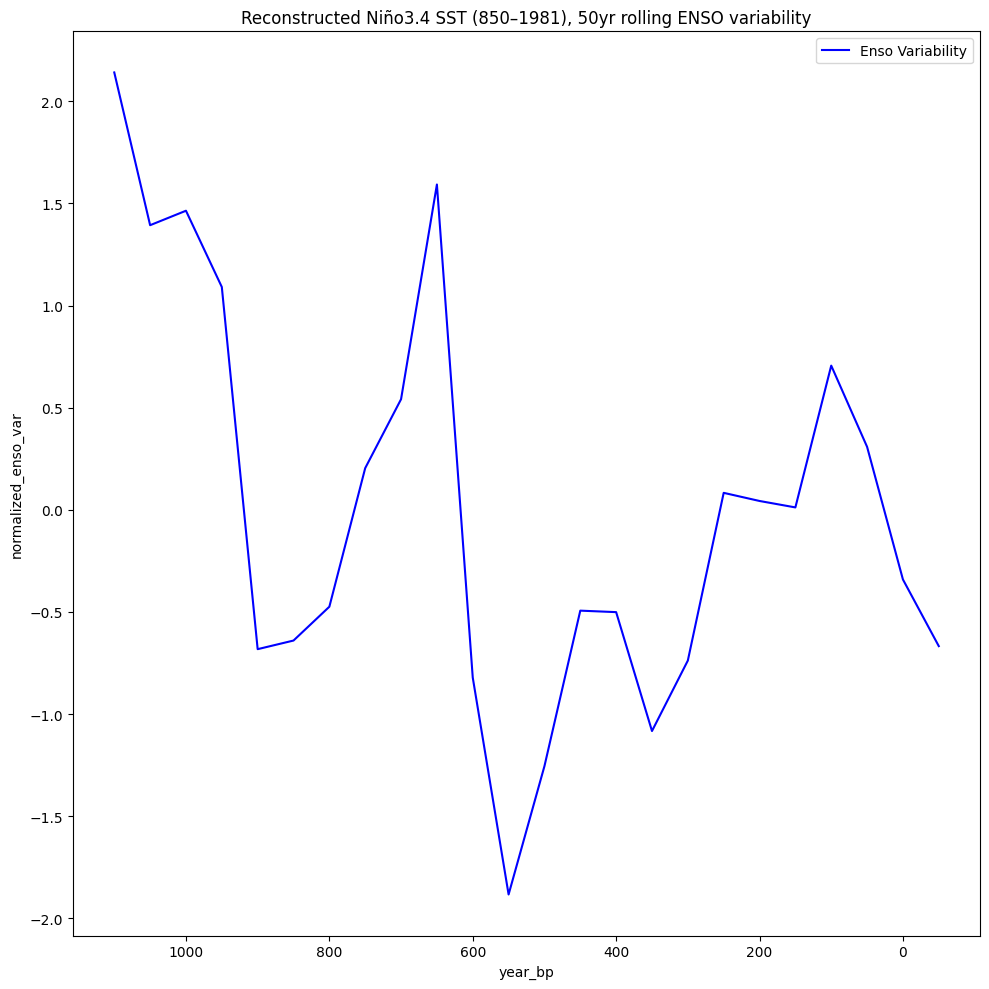

In [ ]:
df2 = pd.read_csv("useable_form_data/reconstruced_sst_Nino_data.tsv", sep = '\t')

# convert to year_bp
df2["year_bp"] = 1950 - df2["year"]

#remove duplicated years
df2 = df2.groupby("year_bp", as_index=False)["SST_NINO3.4_RECONSTRUTED"].mean()

# sort by bp
df2 = df2.sort_values("year_bp")

# ensure continuous yearly time axis
new_year = np.arange(df2["year_bp"].min(), df2["year_bp"].max() + 1, 1)
df2 = df2.set_index("year_bp").reindex(new_year)
df2.index.name = "year_bp"

#  interpolate missing values (if any)
# df2["SST_NINO3.4_RECONSTRUTED"] = df2["SST_NINO3.4_RECONSTRUTED"].interpolate(method="index", limit=5)
df2_allyears = df2.reset_index()

#detrent to remove bias
df2_allyears["trend"] = df2_allyears["SST_NINO3.4_RECONSTRUTED"].rolling(
    window=300,
    center=True,
    min_periods=100
).mean()

df2_allyears["residual"] = (
    df2_allyears["SST_NINO3.4_RECONSTRUTED"] - df2_allyears["trend"]
)

# rolling standard deviation (ENSO variability)
df2_allyears["enso_var"] = df2_allyears["residual"].rolling(window=rolling_std, 
                                                            center=True, 
                                                            min_periods=min_periods).std()

# normalize (z-score)
df2_allyears["normalized_enso_var"] = (
    (df2_allyears["enso_var"] - df2_allyears["enso_var"].mean()) /
    df2_allyears["enso_var"].std()
)

df2_final = bin_to_nyr(df2_allyears, "normalized_enso_var", bin_size)

# plot
create_timeseries(
    df2_final,
    "year_bp",
    "normalized_enso_var",
    "Reconstructed Niño3.4 SST (850–1981), 50yr rolling ENSO variability",
)

data 4

tree rings data

excel already in year and var

starting year 900 (so not a big dataset)

ensovar = 21-year running variance

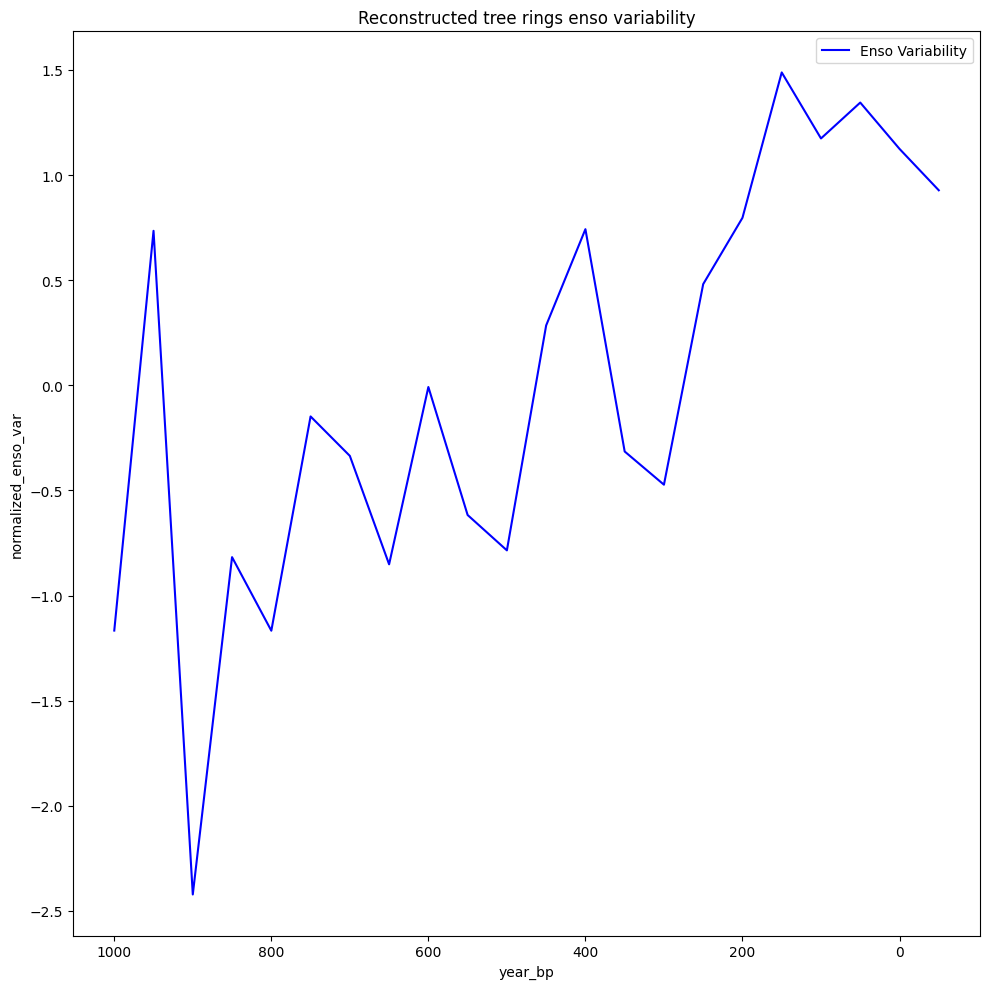

In [ ]:

df4 = pd.read_csv("useable_form_data/tree_rings_processed_data.tsv", sep = '\t')

# remove missing enso variance values
df4 = df4.dropna(subset=["ensovar"]).copy()

#convert to bp
df4["year_bp"] = 1950 - df4["age"]

# from variance to std
df4["enso_var"] = np.sqrt(df4["ensovar"])


df4["normalized_enso_var"] = (
    (df4["enso_var"] - df4["enso_var"].mean()) /
    df4["enso_var"].std()
)

# df4["enso_smooth"] = df4["normalized_enso_var"].rolling(
#     window=50, center=True
# ).mean()
df4_final = bin_to_nyr(df4, "normalized_enso_var", bin_size)

create_timeseries(
    df4_final,
    "year_bp",
    "normalized_enso_var",
    "Reconstructed tree rings enso variability",
)

coral fosil data

dict_keys(['__header__', '__version__', '__globals__', 'spl17', 'spl13', 'm2', 'nb12', 'p11', 'p26', 'p2', 'p34', 'p37', 'p381', 'p382', 'p40', 'p43', 'p49', 'v10', 'v11', 'v13', 'v28', 'v30', 'v33', 'v8', 'mcgregor13', 'x12_d2_5', 'x13_fs21_36', 'x12_d1_6', 'x12_d1_4', 'x12_d2_1', 'x13_fs21_51', 'x13_fs21_14', 'x13_fs21_38', 'x13_fs27_2', 'x13_fs21_15', 'x13_fs21_40', 'x13_fs21_22', 'x13_fs21_45a', 'x13_fs21_45b', 'x13_fs21_16', 'x13_fs22_8'])
spl17 (1, 1)
spl13 (1, 1)
m2 (1, 1)
nb12 (1, 1)
p11 (1, 1)
p26 (1, 1)
p2 (1, 1)
p34 (1, 1)
p37 (1, 1)
p381 (1, 1)
p382 (1, 1)
p40 (1, 1)
p43 (1, 1)
p49 (1, 1)
v10 (1, 1)
v11 (1, 1)
v13 (1, 1)
v28 (1, 1)
v30 (1, 1)
v33 (1, 1)
v8 (1, 1)
mcgregor13 (1, 1)
x12_d2_5 (1, 1)
x13_fs21_36 (1, 1)
x12_d1_6 (1, 1)
x12_d1_4 (1, 1)
x12_d2_1 (1, 1)
x13_fs21_51 (1, 1)
x13_fs21_14 (1, 1)
x13_fs21_38 (1, 1)
x13_fs27_2 (1, 1)
x13_fs21_15 (1, 1)
x13_fs21_40 (1, 1)
x13_fs21_22 (1, 1)
x13_fs21_45a (1, 1)
x13_fs21_45b (1, 1)
x13_fs21_16 (1, 1)
x13_fs22_8 (1, 1)
done
[

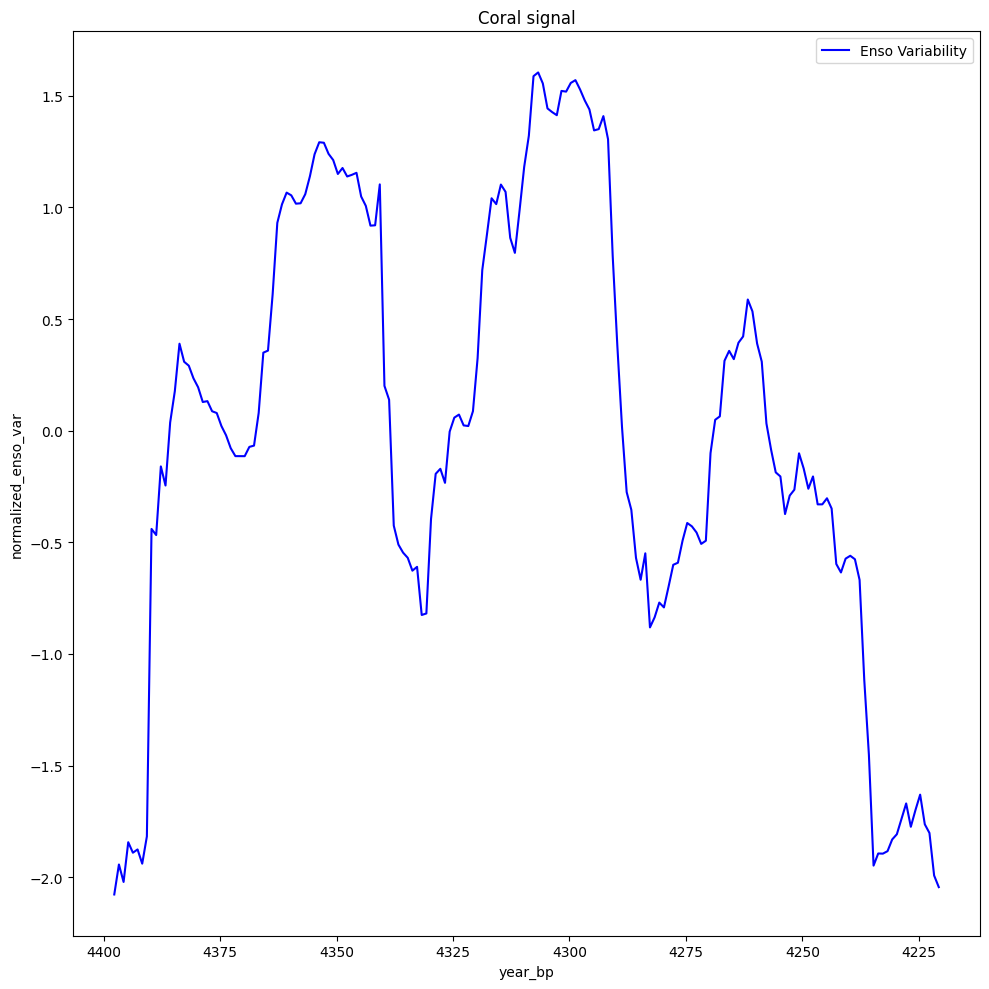

In [8]:
data = loadmat("useable_form_data/2019_fossil_coral_dataset.mat")
print(data.keys())

for key in data:
    if not key.startswith("__"):
        print(key, data[key].shape)

print("done")

rec = data["mcgregor13"]
date = np.ravel(rec["date"][0, 0])
print(date[:10])
print(rec.dtype.names)
# time is in CE
time = np.ravel(rec["time"][0, 0])
even = np.ravel(rec["even"][0, 0])
date = np.ravel(rec["date"][0, 0])

df_coral = pd.DataFrame({
    "time": time,
    "proxy": even,
    "date": date,
}).dropna()
# date is in CE years
print("date range:", date.min(), date.max())
print("time range:", time.min(), time.max())
print(len(even))
print(len(date))
# date range = 4220.708 4397.125
df_coral["year_bp"] = df_coral["date"]
df_coral = df_coral.rename(columns={"proxy": "coral_signal"})

#sort on years
df_coral = df_coral.sort_values("year_bp")

# removing duplicates
df_coral = df_coral.groupby("year_bp", as_index=False)["coral_signal"].mean()

# making it a continous timeline
new_year = np.arange(df_coral["year_bp"].min(), df_coral["year_bp"].max() + 1)
df_coral = df_coral.set_index("year_bp").reindex(new_year)
df_coral.index.name = "year_bp"

# removing small gaps
df_coral["coral_signal"] = df_coral["coral_signal"].interpolate(
    method="index", limit=5
)

df_coral["enso_var"] = df_coral["coral_signal"].rolling(
    window=rolling_std, center=True, min_periods=min_periods
).std()

df_coral["normalized_enso_var"] = (
    (df_coral["enso_var"] - df_coral["enso_var"].mean()) /
    df_coral["enso_var"].std()
)

df_coral = df_coral.reset_index()

create_timeseries(df_coral, "year_bp", "normalized_enso_var", "Coral signal")

current data set 6

diablo Speleothems

age_calkabp = age in ka bp

d18O is what we need

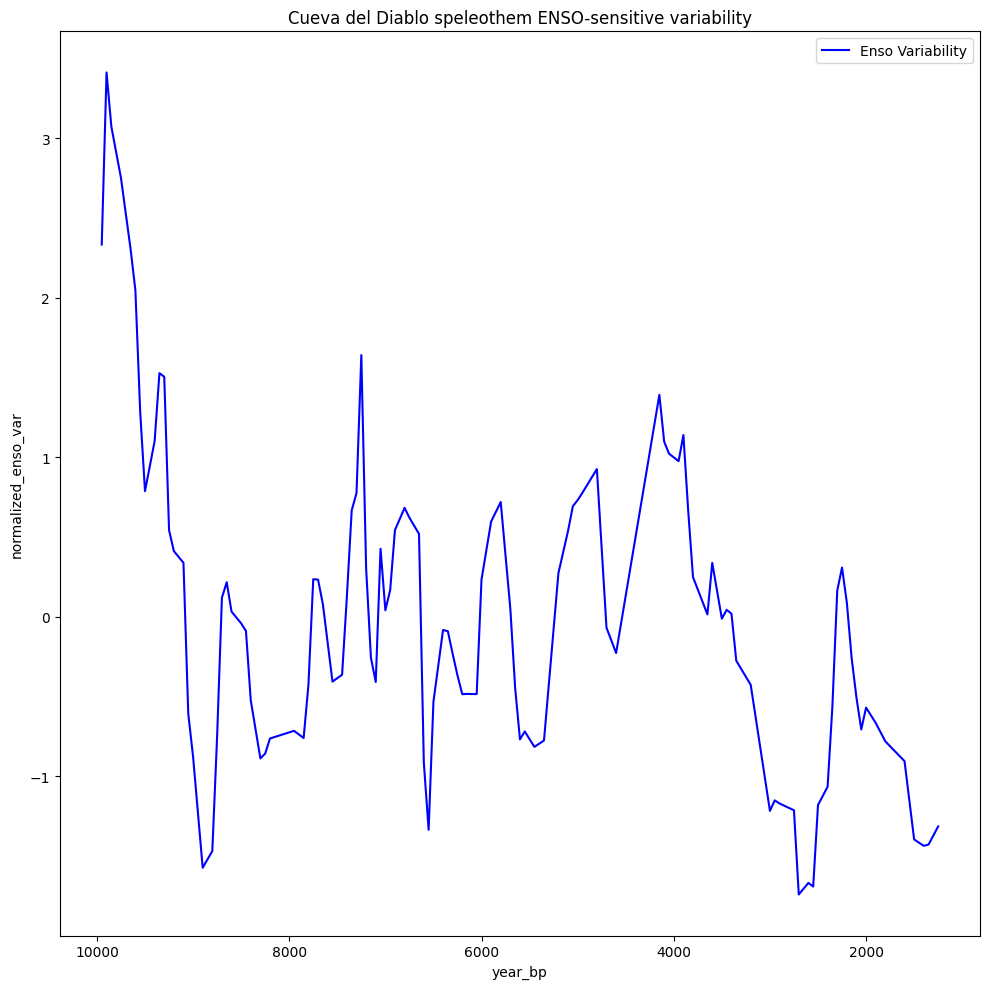

In [ ]:
df6 = pd.read_csv("useable_form_data/diablo_usefulldata.tsv", sep="\t")

# convert to year bp
df6["year_bp"] = df6["age_calkaBP"] * 1000

# remove missing valyes
df6 = df6.dropna(subset=["d18O"]).copy()

# more negative means stronger enso
df6["d18O"] = -df6["d18O"]

# sort by time
df6 = df6.sort_values("year_bp")

# identify large gaps
df6["difference"] = df6["year_bp"].diff()
df6["segment"] = (df6["difference"] > 200).cumsum()

# compute rolling std within segments
df6["enso_var"] = np.nan

for _, seg in df6.groupby("segment"):
    if len(seg) < 10:
        continue

    # --- DETREND (small window, local) ---
    seg["trend"] = seg["d18O"].rolling(
        window=100,  # important: smaller than PC1/SST
        center=True,
        min_periods=30
    ).mean()

    seg["residual"] = seg["d18O"] - seg["trend"]

    df6.loc[seg.index, "enso_var"] = seg["residual"].rolling(
        window=10, center=True, min_periods=5
    ).std()

# normalize
df6["normalized_enso_var"] = (
    (df6["enso_var"] - df6["enso_var"].mean()) /
    df6["enso_var"].std()
)

# plot only valid values
df6_plot = df6.dropna(subset=["normalized_enso_var"]).copy()

df6_final = bin_to_nyr(df6_plot, "normalized_enso_var", bin_size)


create_timeseries(
    df6_final,
    "year_bp",
    "normalized_enso_var",
    "Cueva del Diablo speleothem ENSO-sensitive variability"
)

data galapogos island

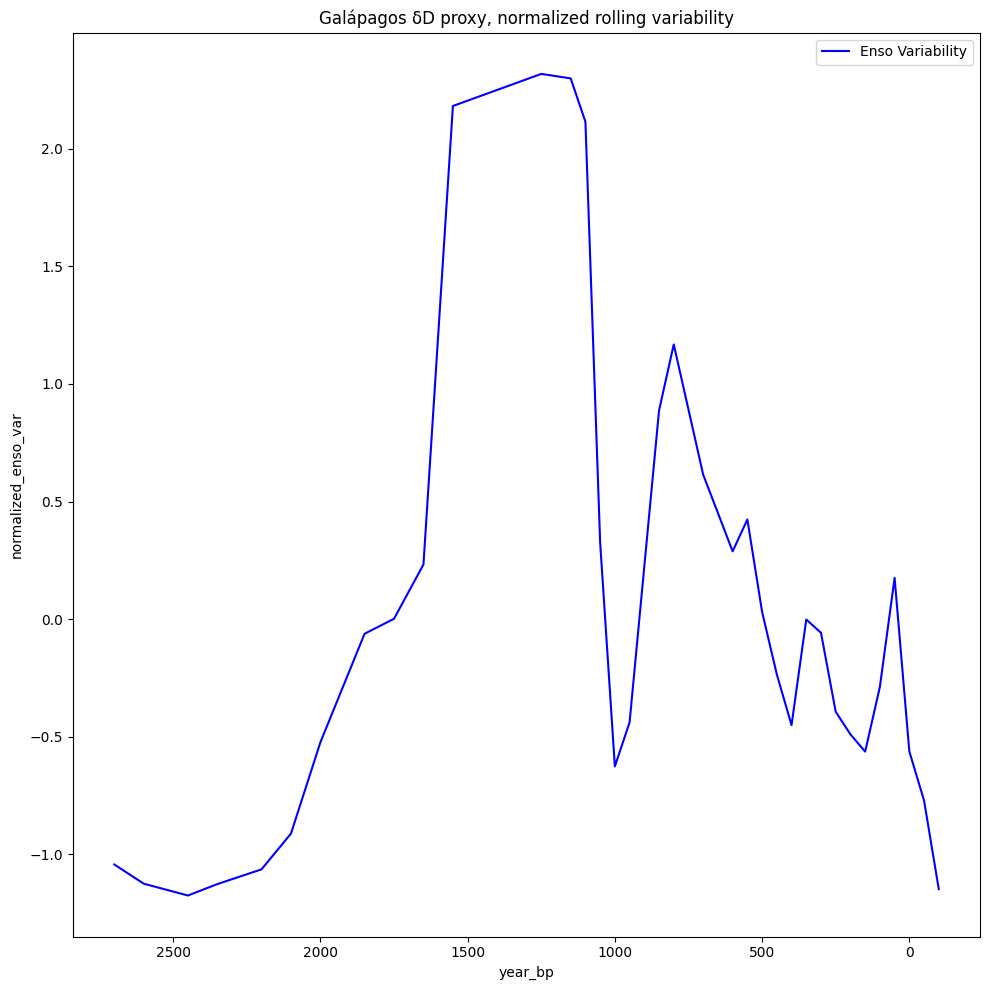

In [ ]:
df8 = pd.read_csv(
    "useable_form_data/EJ7-MW1_EJ-N-1_biom_dD.tab",
    sep="\t",
    skiprows=20
)

proxy_col = "δD [‰ SMOW] (biomarker, bottom)"
# proxy_col = "δD [‰ SMOW] (biomarker, dinoflagellate)"

# keep needed columns
df8 = df8[["Age [ka BP]", proxy_col]].dropna().copy()

# convert to year BP
df8["year_bp"] = (df8["Age [ka BP]"] * 1000).astype(int)

# sort on year bp
df8 = df8.sort_values("year_bp")


# bin to 10-year intervals
df8["year_bp_10"] = (df8["year_bp"] // 10) * 10

# average within 10-year bins
#remove duplicated years
df8 = df8.groupby("year_bp_10", as_index=False)[proxy_col].mean()
df8 = df8.rename(columns={"year_bp_10": "year_bp"})

# sort
df8 = df8.sort_values("year_bp")


# detrend
# 20 bins = 200 years, which is 4x your 50-year variability window
df8["trend"] = df8[proxy_col].rolling(
    window=20,
    center=True,
    min_periods=8
).mean()

df8["residual"] = df8[proxy_col] - df8["trend"]

# rolling std over 5 bins = 50-year variability
df8["enso_var"] = df8["residual"].rolling(
    window=(rolling_std // 10), center=True, min_periods=( min_periods // 10)
).std() 

# normalize
df8["normalized_enso_var"] = (
    (df8["enso_var"] - df8["enso_var"].mean()) /
    df8["enso_var"].std()
)

df8_plot = df8.dropna(subset=["normalized_enso_var"]).copy()

df8_final = bin_to_nyr(df8_plot, "normalized_enso_var", bin_size)

create_timeseries(
    df8_final,
    "year_bp",
    "normalized_enso_var",
    "Galápagos δD proxy, normalized rolling variability"
)

# Comparing the proxies
comparison on proxies in same timewindow (most are around 2000)

In [11]:
def combining_proxies(df, name, max_gap=2):
    temp_df = df[["year_bp", "normalized_enso_var"]].dropna()
    temp_df = temp_df.set_index(["year_bp"])

    temp_df = temp_df.reindex(year_window)

    temp_df["normalized_enso_var"] = temp_df["normalized_enso_var"].interpolate(
        method='index',
        limit=max_gap
    )
    
    return temp_df.rename(columns={"normalized_enso_var": name})

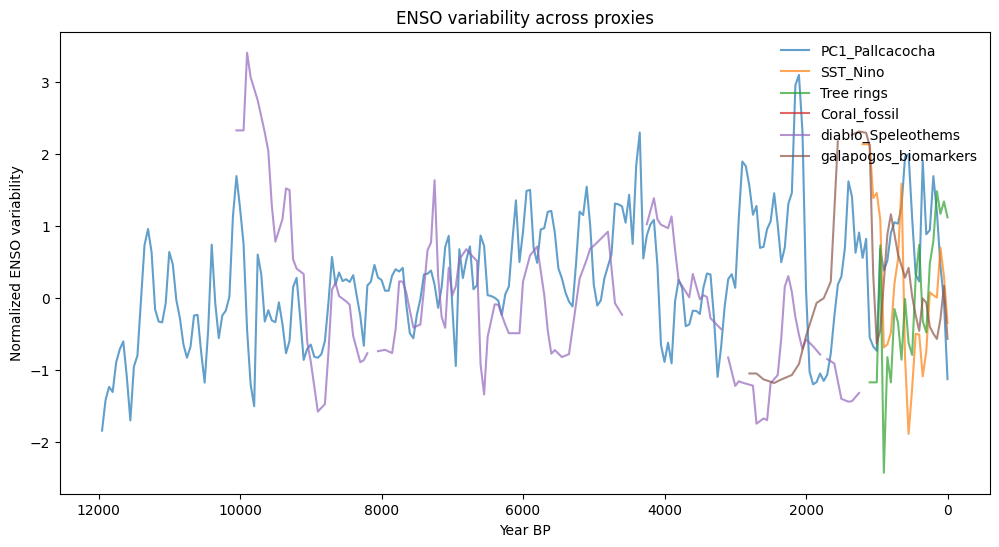

In [ ]:
year_window = np.arange(0, 12000, bin_size)

df_combined = pd.concat([
    combining_proxies(df1_final, "PC1_Pallcacocha"),
    combining_proxies(df2_final,  "SST_Nino"),
    combining_proxies(df4_final, "Tree rings"),
    # combining_proxies(df_coral, "Coral_fossil"), #too small
    # combining_proxies(df6_final, "diablo_Speleothems"),
    combining_proxies(df8_final, "galapogos_biomarkers")
], axis=1)

df_combined = df_combined.reset_index().rename(columns={"index": "year_bp"})

plt.figure(figsize=(12,6))

for col in df_combined.columns[1:]:
    plt.plot(df_combined["year_bp"], df_combined[col], label=col, alpha=0.7, linewidth=1.5)

plt.gca().invert_xaxis()
plt.legend(loc="upper right", frameon=False)
plt.title("ENSO variability across proxies")
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.show()

Comparing pairwise correlation

In [13]:
# define overlap window
start = 0
end = 2000

# select only relevant columns
cols = [
    "PC1_Pallcacocha",
    "SST_Nino",
    "Tree rings",
    # "Coral_fossil",
    # "diablo_Speleothems",
    "galapogos_biomarkers"
]

# subset + window
df_corr = df_combined[
    (df_combined["year_bp"] >= start) &
    (df_combined["year_bp"] <= end)
][["year_bp"] + cols].copy()

# cross correlation analysis
# compute correlation matrix (pairwise, ignores NaNs automatically)
corr_matrix = df_corr[cols].corr()

corr_matrix.round(2).to_csv("correlation_matrix_normalised2.csv")

for col in df_combined.columns[1:]:
    print(col,
          round(df_combined[col].mean(), 2),
          round(df_combined[col].std(), 2))


# for c1 in cols:
#     for c2 in cols:
#         n = df_corr[[c1, c2]].dropna().shape[0]
#         print(f"{c1} vs {c2}: n={n}")



PC1_Pallcacocha 0.26 0.85
SST_Nino 0.2 1.13
Tree rings -0.14 1.01
galapogos_biomarkers 0.01 1.08


Gaussian Process Regression

In [14]:
# using inverse variance weighting
def weighted_composite(df, columns):
    variance = df[columns].var(skipna=True)

    # remove division by zero
    variance = variance.replace(0, np.nan)

    weights = 1 / variance
    # normalizing
    weights = weights / weights.sum()

    def weighted_on_year(row):
        # get rows that have values in that year
        valid = row[columns].notna()
        if valid.sum() == 0:
            return np.nan

        # weight only applied for proxies that excist
        row_weights = weights[valid]
        row_weights = row_weights / row_weights.sum()

        # weighted composite for that year
        return np.sum(row[columns][valid] * row_weights)
    
    return df.apply(weighted_on_year, axis=1)



In [15]:
# func that doees that
def run_gpr_reconstruction(df, columns ,year_window, kernel, composite_method="mean"):
    # shared ENSO signal
    df = df.copy()
    if composite_method == "median":
        df["ENSO_composite"] = df[columns].median(axis=1, skipna=True)
    elif composite_method == "mean":
        df["ENSO_composite"] = df[columns].mean(axis=1, skipna=True)
    elif composite_method == "weighted":
        df["ENSO_composite"] = weighted_composite(df, columns)
        
    df["ENSO_spread"] = df[columns].std(axis=1, skipna=True)

    df_gpr = df.dropna(subset=["ENSO_composite"]).copy()

    # X = time, y = ENSO variability
    X = df_gpr["year_bp"].values.reshape(-1, 1) / 1000
    y = df_gpr["ENSO_composite"].values

    # proxy disagreement as observation noise
    alpha = df_gpr["ENSO_spread"].fillna(0.1).values ** 2
    alpha = np.maximum(alpha, 1e-4)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha,
        n_restarts_optimizer=10,
        normalize_y=True
    )
    gpr.fit(X, y)

    X_pred = year_window.reshape(-1, 1) / 1000
    y_pred, y_std = gpr.predict(X_pred, return_std=True)

    df_gpr_pred = pd.DataFrame({
        "year_bp": year_window,
        "y_pred": y_pred,
        "y_std": y_std
    })

    return gpr, df_gpr, df_gpr_pred


def create_harmonized_plot(df_gpr, df_gpr_pred, save_path=None):
    plt.figure(figsize=(12, 6))

    # composite is the mean(proxy at each time)
    # it is the proxies combined
    plt.scatter(
        df_gpr["year_bp"],
        df_gpr["ENSO_composite"],
        color="black",
        s=35,
        label="ENSO composite"
    )

    # GP mean curve
    plt.plot(
        df_gpr_pred["year_bp"],
        df_gpr_pred["y_pred"],
        linewidth=2,
        label="GPR reconstructed ENSO"
    )

    # uncertainty around ±2 standard deviations
    plt.fill_between(
        df_gpr_pred["year_bp"],
        df_gpr_pred["y_pred"] - 2 * df_gpr_pred["y_std"],
        df_gpr_pred["y_pred"] + 2 * df_gpr_pred["y_std"],
        alpha=0.25,
        label="Uncertainty ±2σ"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Year BP")
    plt.ylabel("Normalized ENSO variability")
    plt.title("Gaussian Process Reconstruction of ENSO variability")
    plt.legend(frameon=False)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

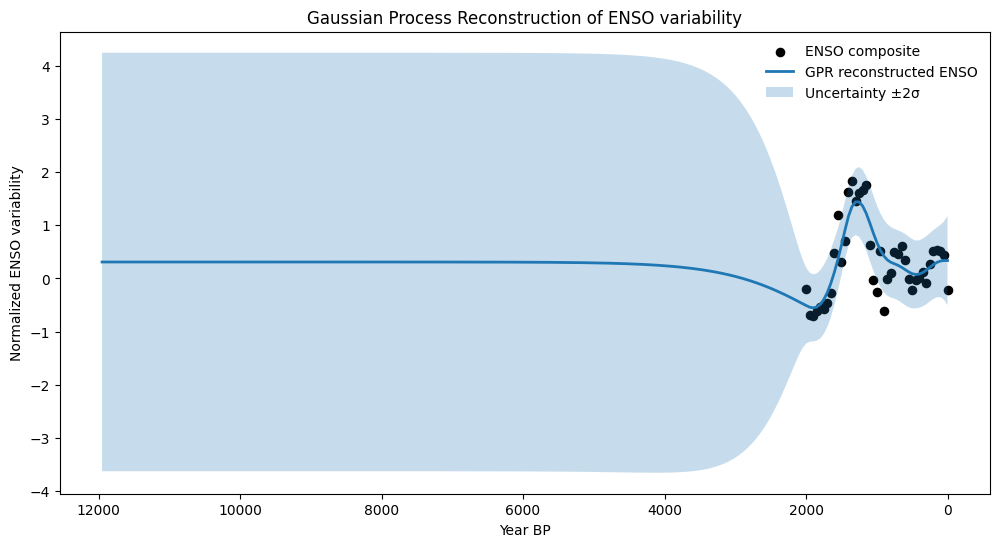

In [16]:
kernel = (
    ConstantKernel(1.0)
    * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5)
    + WhiteKernel(noise_level=0.1)
)

gpr_model, df_gpr, df_gpr_pred = run_gpr_reconstruction(
    df=df_corr,
    columns=cols,
    year_window=year_window,
    kernel=kernel
)

create_harmonized_plot(df_gpr, df_gpr_pred)


Base Line model based on 800 nino3.4

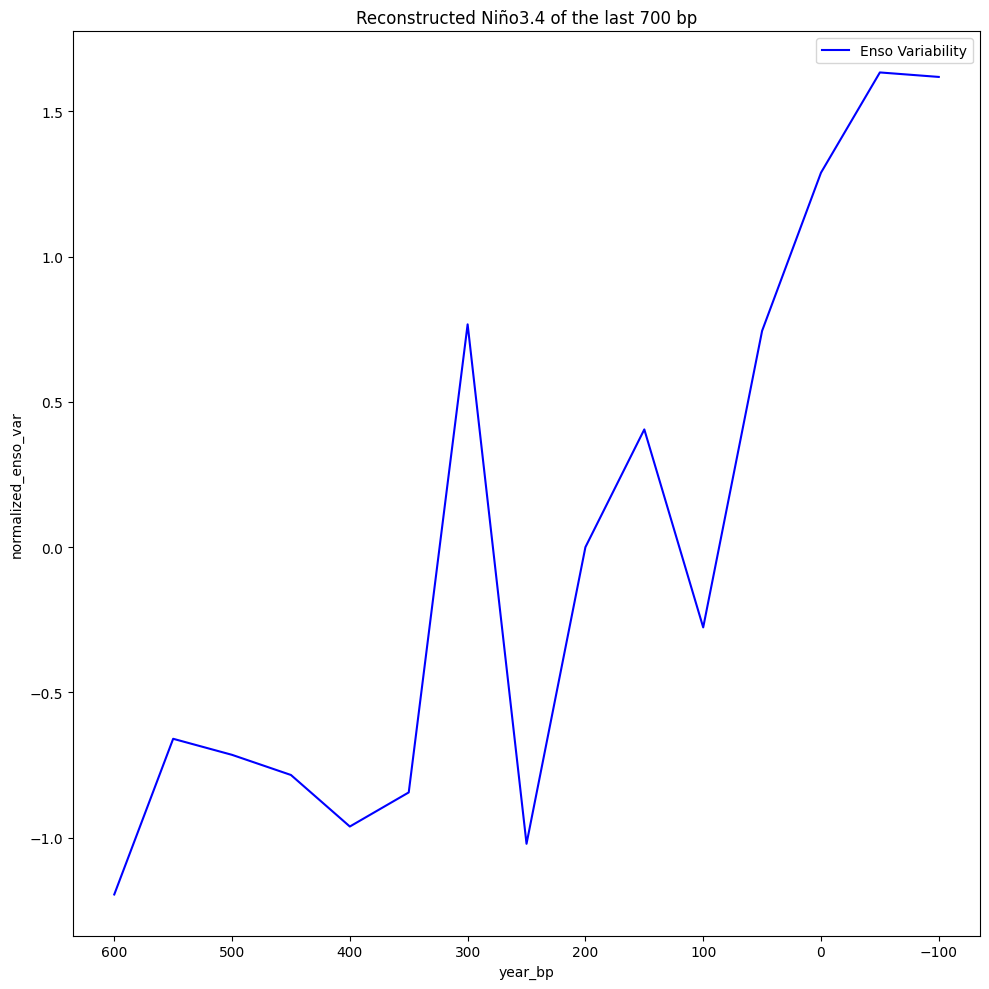

In [ ]:
# processing the baseline_data
df_baseline = pd.read_csv("base_line_data/Nino3_4_processed.tsv", sep = '\t')

df_baseline["year_bp"] = 1950 - df_baseline["age_AD"]



#remove duplicated years
df_baseline = df_baseline.groupby("year_bp", as_index=False)["sst.anom"].mean()
# sort by bp
df_baseline = df_baseline.sort_values("year_bp")

#  interpolate not necessary since it is consistent data

# rolling standard deviation (ENSO variability)
df_baseline["enso_var"] = df_baseline["sst.anom"].rolling(window=rolling_std, center=True, min_periods=min_periods).std()

# normalize (z-score)
df_baseline["normalized_enso_var"] = (
    (df_baseline["enso_var"] - df_baseline["enso_var"].mean()) /
    df_baseline["enso_var"].std()
)

df_baseline = bin_to_nyr(df_baseline, "normalized_enso_var", bin_size)

# plot
create_timeseries(
    df_baseline,
    "year_bp",
    "normalized_enso_var",
    "Reconstructed Niño3.4 of the last 700 bp"

)

Comparing GPR with baseline

    year_bp    y_pred     y_std  baseline_ENSO
0         0  0.336893  0.419551       1.288662
1        50  0.337214  0.368394       0.744308
2       100  0.327586  0.340207      -0.276225
3       150  0.301973  0.328584       0.405121
4       200  0.260588  0.324204      -0.000040
5       250  0.208395  0.321867      -1.020930
6       300  0.154737  0.320432       0.766747
7       350  0.110580  0.318899      -0.844159
8       400  0.082308  0.317559      -0.961510
9       450  0.074832  0.319727      -0.784139
10      500  0.090028  0.326572      -0.714842
11      550  0.123735  0.333283      -0.659568
12      600  0.167214  0.335580      -1.195391


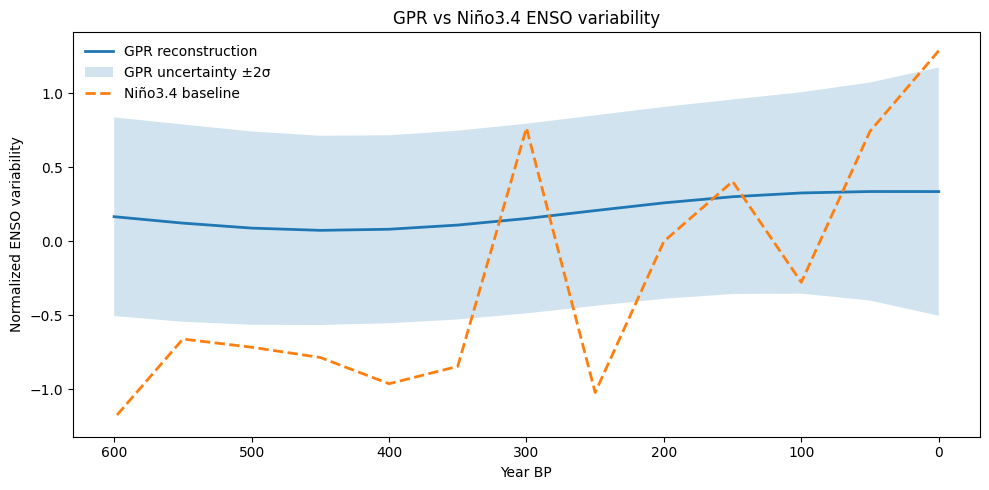

Pearson correlation: 0.691
spearman correlation: 0.582
Rmse 0.844
Mean uncertainty: 0.337


In [18]:
df_baseline_compare = df_baseline.rename(
    columns={"normalized_enso_var": "baseline_ENSO"}
)[["year_bp", "baseline_ENSO"]]


df_compare = pd.merge(
    df_gpr_pred,
    df_baseline_compare,
    on="year_bp",
    how="inner"
)

df_compare = df_compare[
    (df_compare["year_bp"] >= 0) &
    (df_compare["year_bp"] <= 600)
].dropna()

print(df_compare)

plt.figure(figsize=(10, 5))

# GPR reconstruction
plt.plot(
    df_compare["year_bp"],
    df_compare["y_pred"],
    label="GPR reconstruction",
    linewidth=2
)

# shows the uncertinty the model has in comparence to basecase
plt.fill_between(
    df_compare["year_bp"],
    df_compare["y_pred"] - 2 * df_compare["y_std"],
    df_compare["y_pred"] + 2 * df_compare["y_std"],
    alpha=0.2,
    label="GPR uncertainty ±2σ"
)

# Baseline (Niño3.4)
plt.plot(
    df_compare["year_bp"],
    df_compare["baseline_ENSO"],
    label="Niño3.4 baseline",
    linestyle="--",
    linewidth=2
)

# Formatting
plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR vs Niño3.4 ENSO variability")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# calc pearson
# measure linear co_variation
# do high values correspond with high values in the baseline
# do lows aling with low
# here: Are the amplitudes of ENSO variability aligned?
pearson_corr = df_compare["y_pred"].corr(df_compare["baseline_ENSO"], method="pearson")
print("Pearson correlation:", round(pearson_corr, 3))

# calc Spearman correlatiom
# looks at rank-based similirity
# Do the patterns match, even if values differ?
spearman_corr = df_compare["y_pred"].corr(df_compare["baseline_ENSO"], method="spearman")
print("spearman correlation:", round(spearman_corr, 3))

# RMSE (tell how far they are appart
# how far are the signals appart from eachother
# the lower, thebetter
Rmse = mean_squared_error(df_compare["baseline_ENSO"], df_compare["y_pred"])
Rmse = (Rmse)**(1/2)
print("Rmse", round(Rmse, 3))

# quantify the uncertainty by getting the main of y_std
mean_uncertainty = df_compare["y_std"].mean()
print("Mean uncertainty:", round(mean_uncertainty, 3))



Temporal analysis

In [19]:
#saving temporal reconstruction

rolling_window_label = rolling_std

os.makedirs("saved_temporal_reconstructions", exist_ok=True)

#saving the reconstruction line
df_gpr_pred_save = df_gpr_pred.copy()
df_gpr_pred_save["rolling_window"] = rolling_window_label

df_gpr_pred_save.to_csv(
    f"saved_temporal_reconstructions/gpr_reconstruction_{rolling_window_label}.csv",
    index=False
)

# saving the metrics
metrics_save = pd.DataFrame([{
    "rolling_window": rolling_window_label,
    "pearson": pearson_corr,
    "spearman": spearman_corr,
    "rmse": Rmse,
    "mean_uncertainty": mean_uncertainty
}])

metrics_save.to_csv(
    f"saved_temporal_reconstructions/metrics_{rolling_window_label}.csv",
    index=False
)

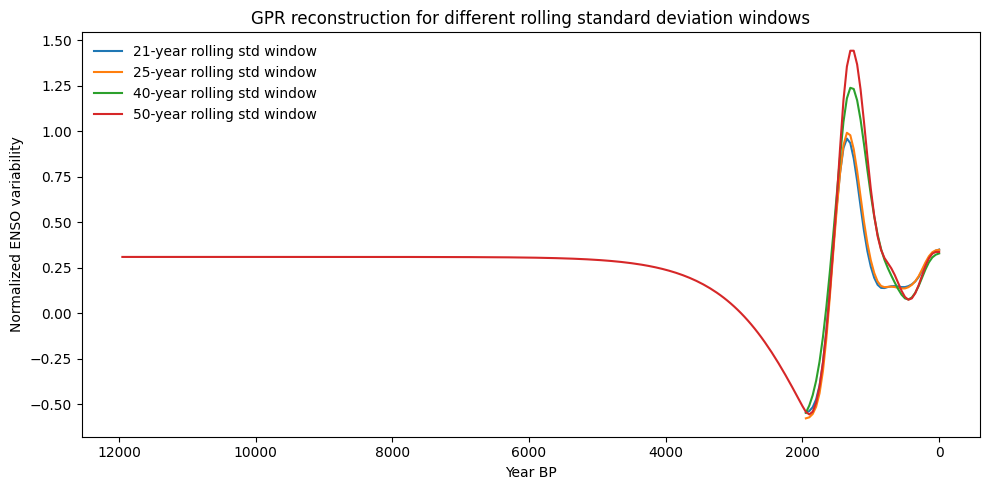

In [20]:
figure_files = glob.glob("saved_temporal_reconstructions/gpr_reconstruction_*.csv")


combined_reconstructions = pd.concat(
    [pd.read_csv(file) for file in figure_files],
    ignore_index=True
)

plt.figure(figsize=(10, 5))

for window, group in combined_reconstructions.groupby("rolling_window"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{window}-year rolling std window"
    )
    
plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for different rolling standard deviation windows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [21]:
# plotting combined figure
metric_files = glob.glob("saved_temporal_reconstructions/metrics_*.csv")

all_metrics = pd.concat(
    [pd.read_csv(file) for file in metric_files],
    ignore_index=True
)

all_metrics = all_metrics.round(3)

all_metrics = all_metrics.sort_values("rolling_window", ascending=False)
print(all_metrics)

all_metrics.to_csv(
    f"saved_temporal_reconstructions/fullmetrics.csv",
    index=False
)

   rolling_window  pearson  spearman   rmse  mean_uncertainty
3              50    0.691     0.582  0.844             0.337
2              40    0.698     0.621  0.807             0.330
1              25    0.693     0.659  0.816             0.308
0              21    0.696     0.665  0.839             0.313


Parameter Comparis

In [22]:

os.makedirs("saved_kernel_reconstructions", exist_ok=True)


def make_kernel(kernel_type, length_scale, fixed=True):
    if fixed:
        bounds = "fixed"
    else:
        bounds = (1e-2, 10) 

    if kernel_type == "matern":
        base = Matern(length_scale=length_scale, length_scale_bounds=bounds, nu=1.5)
    elif kernel_type == "rbf":
        base = RBF(length_scale=length_scale, length_scale_bounds=bounds)
    elif kernel_type == "rq":
        base = RationalQuadratic(length_scale=length_scale, alpha=1.0, length_scale_bounds=bounds)
    else:
        raise ValueError("Unknown kernel")

    return ConstantKernel(1.0) * base + WhiteKernel(noise_level=0.1)

kernels = ["matern", "rbf", "rq"]
length_scales = [0.3, 0.5, 1.0]
fixed_options = [True, False]

results = []

for kernel in kernels:
    for length_scale in length_scales:
        for option in fixed_options:

            kernel_x = make_kernel(kernel, length_scale, option)

            gpr_model, df_gpr, df_gpr_pred = run_gpr_reconstruction(
                df=df_corr,
                columns=cols,
                year_window=year_window,
                kernel=kernel_x
            )

            df_save = df_gpr_pred.copy()
            df_save["kernel"] = kernel
            df_save["length_scale"] = length_scale
            df_save["fixed"] = option

            filename = f"saved_kernel_reconstructions/gpr_{kernel}_ls{length_scale}_fixed{option}.csv"
            df_save.to_csv(filename, index=False)

            # create_harmonized_plot(df_gpr, df_gpr_pred)

            df_compare = pd.merge(
                df_gpr_pred,
                df_baseline_compare,
                on="year_bp",
                how="inner"
            ).dropna()

            pearson = df_compare["y_pred"].corr(df_compare["baseline_ENSO"], method="pearson")
            spearman = df_compare["y_pred"].corr(df_compare["baseline_ENSO"], method="spearman")

            Rmse = mean_squared_error(df_compare["baseline_ENSO"], df_compare["y_pred"])
            Rmse = (Rmse)**(1/2)

            mean_uncertainty = df_compare["y_std"].mean()

            results.append({
                "kernel": kernel,
                "length_scale": length_scale,
                "fixed": option,
                "pearson": pearson,
                "spearman": spearman,
                "rmse": Rmse,
                "mean_uncertainty": mean_uncertainty
            })

df_results = pd.DataFrame(results)
df_results = df_results.round(3)
df_results.to_csv("saved_kernel_reconstructions/kernel_metrics.csv", index=False)
print(df_results.sort_values("rmse"))



c:\Users\kayad\University Year 2025-2026\ENSO bachelor Thesis\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\kayad\University Year 2025-2026\ENSO bachelor Thesis\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


    kernel  length_scale  fixed  pearson  spearman   rmse  mean_uncertainty
8      rbf           0.5   True    0.761     0.610  0.817             0.360
4   matern           1.0   True    0.691     0.582  0.844             0.337
2   matern           0.5   True    0.614     0.522  0.848             0.323
6      rbf           0.3   True    0.755     0.621  0.850             0.334
12      rq           0.3   True    0.659     0.577  0.851             0.327
0   matern           0.3   True    0.520     0.473  0.854             0.312
14      rq           0.5   True    0.523     0.484  0.855             0.320
16      rq           1.0   True    0.495     0.484  0.857             0.317
13      rq           0.3  False    0.490     0.484  0.860             0.316
11     rbf           1.0  False    0.490     0.484  0.860             0.316
15      rq           0.5  False    0.490     0.484  0.860             0.316
9      rbf           0.5  False    0.490     0.484  0.860             0.316
17      rq  

c:\Users\kayad\University Year 2025-2026\ENSO bachelor Thesis\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


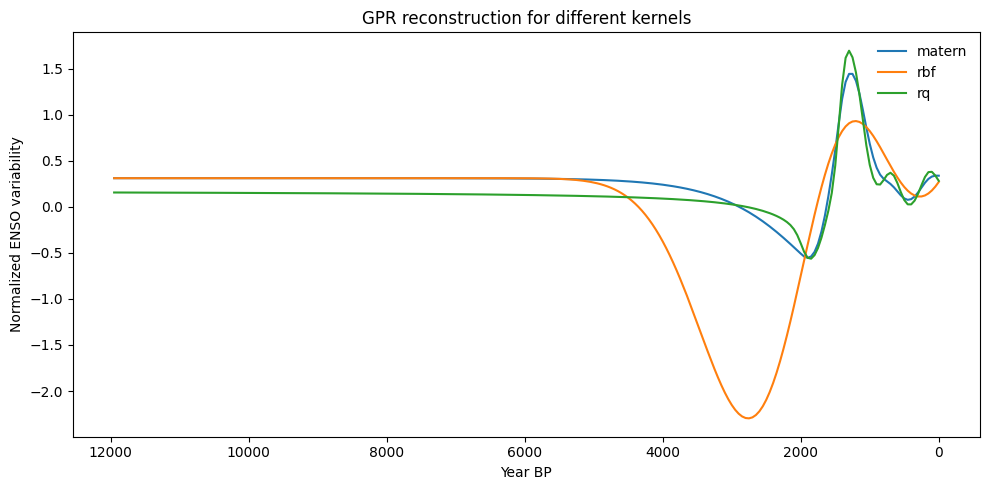

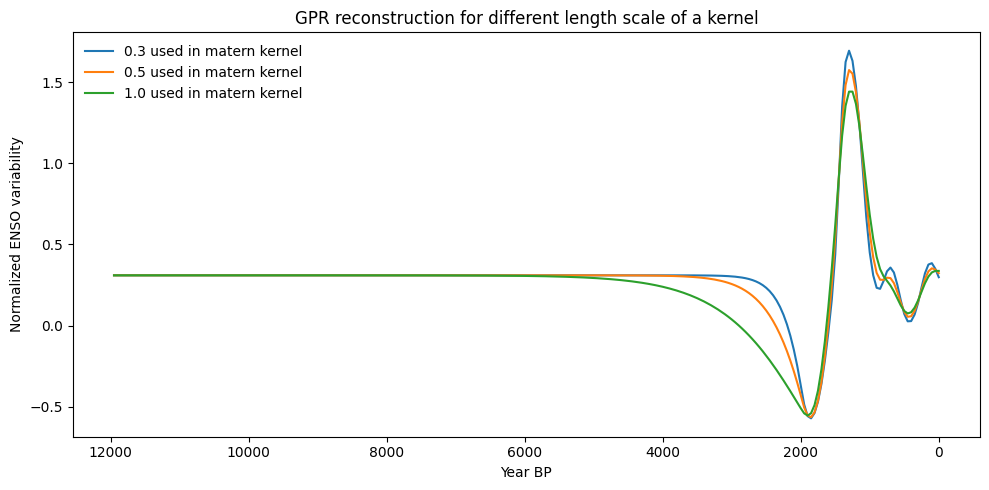

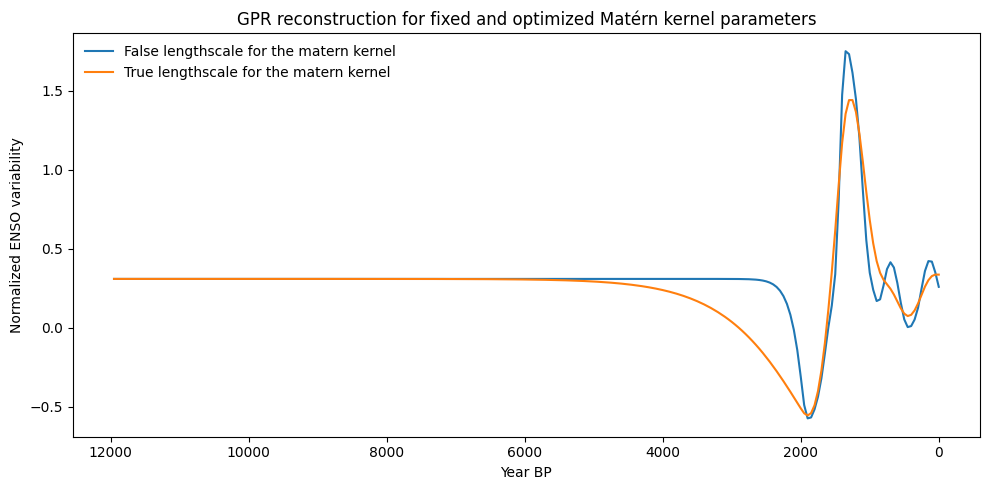

In [23]:
# creating plots
kernel_files = glob.glob("saved_kernel_reconstructions/gpr_*_ls1.0_fixedTrue.csv")
length_files = glob.glob("saved_kernel_reconstructions/gpr_matern_ls*_fixedTrue.csv")
fixed_files = glob.glob("saved_kernel_reconstructions/gpr_matern_ls1.0_fixed*.csv")

kernel_reconstructions = pd.concat(
    [pd.read_csv(file) for file in kernel_files],
    ignore_index=True
)

length_reconstructions = pd.concat(
    [pd.read_csv(file) for file in length_files],
    ignore_index=True
)

fixed_reconstructions = pd.concat(
    [pd.read_csv(file) for file in fixed_files],
    ignore_index=True
)

plt.figure(figsize=(10, 5))

for kernel, group in kernel_reconstructions.groupby("kernel"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{kernel}"
    )

plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for different kernels")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

for length_scale, group in length_reconstructions.groupby("length_scale"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{length_scale} used in matern kernel"
    )

plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for different length scale of a kernel")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

for fixed, group in fixed_reconstructions.groupby("fixed"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{fixed} lengthscale for the matern kernel"
    )

plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for fixed and optimized Matérn kernel parameters")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

proxy analysis

In [24]:
os.makedirs('saved_proxy_reconstructions', exist_ok=True)

options = ["mean", "median", "weighted"]

proxy_results = []

# create a set containg all possible proxies combo with n-1
proxy_sets = {"all_proxies": cols}
for proxy in cols:
    proxy_sets[f"without_{proxy}"] = [c for c in cols if c != proxy]

kernel = (
    ConstantKernel(1.0)
    * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5)
    + WhiteKernel(noise_level=0.1)
)


for option in options:
    for name, selected_cols in proxy_sets.items():
        gpr_model, df_gpr, df_gpr_pred = run_gpr_reconstruction(
            df=df_corr,
            columns=selected_cols,
            year_window=year_window,
            kernel=kernel,
            composite_method=option
        )

        df_save = df_gpr_pred.copy()
        df_save["composite"] = option
        df_save["removed"] = name

        filename = f"saved_proxy_reconstructions/gpr_method{option}_{name}.csv"
        df_save.to_csv(filename, index=False)

        df_compare = pd.merge(
            df_gpr_pred,
            df_baseline_compare,
            on="year_bp",
            how="inner"
        )

        pearson = df_compare["y_pred"].corr(
            df_compare["baseline_ENSO"],
            method="pearson"
        )

        spearman = df_compare["y_pred"].corr(
            df_compare["baseline_ENSO"],
            method="spearman"
        )

        rmse = np.sqrt(mean_squared_error(
            df_compare["baseline_ENSO"],
            df_compare["y_pred"]
        ))

        mean_uncertainty = df_compare["y_std"].mean()

        proxy_results.append({
            "composite_method": option,
            "setup": name,
            "n_proxies": len(selected_cols),
            "removed_proxy": None if name == "all_proxies" else name.replace("without_", ""),
            "pearson": pearson,
            "spearman": spearman,
            "rmse": rmse,
            "mean_uncertainty": mean_uncertainty
        })

df_p_results = pd.DataFrame(proxy_results)
df_p_results = df_p_results.round(3)
print(df_p_results.sort_values("rmse"))
df_p_results.to_csv("saved_proxy_reconstructions/kernel_metrics.csv", index=False)




c:\Users\kayad\University Year 2025-2026\ENSO bachelor Thesis\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\kayad\University Year 2025-2026\ENSO bachelor Thesis\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\kayad\University Year 2025-2026\ENSO bachelor Thesis\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may 

   composite_method                         setup  n_proxies  \
1              mean       without_PC1_Pallcacocha          3   
11         weighted       without_PC1_Pallcacocha          3   
6            median       without_PC1_Pallcacocha          3   
5            median                   all_proxies          4   
0              mean                   all_proxies          4   
10         weighted                   all_proxies          4   
8            median            without_Tree rings          3   
4              mean  without_galapogos_biomarkers          3   
9            median  without_galapogos_biomarkers          3   
14         weighted  without_galapogos_biomarkers          3   
3              mean            without_Tree rings          3   
2              mean              without_SST_Nino          3   
12         weighted              without_SST_Nino          3   
13         weighted            without_Tree rings          3   
7            median              without

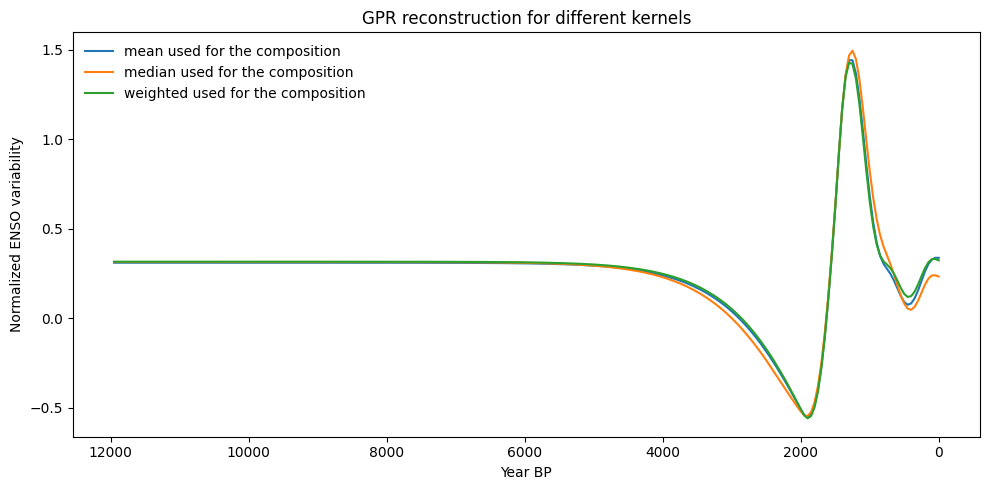

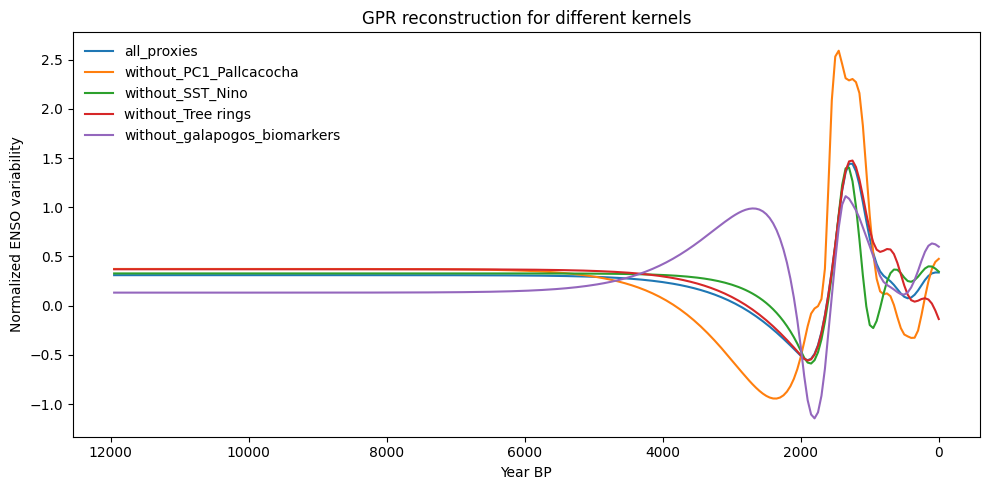

In [25]:
composition_files = glob.glob("saved_proxy_reconstructions/gpr_method*_all_proxies.csv")
proxy_files = glob.glob("saved_proxy_reconstructions/gpr_methodmean_*.csv")

composition_reconstructions = pd.concat(
    [pd.read_csv(file) for file in composition_files],
    ignore_index=True
)

proxy_reconstructions = pd.concat(
    [pd.read_csv(file) for file in proxy_files],
    ignore_index=True
)

plt.figure(figsize=(10, 5))

for composition, group in composition_reconstructions.groupby("composite"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{composition} used for the composition"
    )

plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for different kernels")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

for proxy, group in proxy_reconstructions.groupby("removed"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{proxy}"
    )

plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for different kernels")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


binning analysis


In [26]:
os.makedirs("saved_binning_reconstructions", exist_ok=True)

# need to run this will making the binning [50, 40, 25]
binning_label = bin_size

#saving the reconstruction line
df_gpr_pred_save = df_gpr_pred.copy()
df_gpr_pred_save["bins"] = binning_label

df_gpr_pred_save.to_csv(
    f"saved_binning_reconstructions/binning_reconstruction_{binning_label}.csv",
    index=False
)

# saving the metrics
metrics_save = pd.DataFrame([{
    "bins": binning_label,
    "pearson": pearson_corr,
    "spearman": spearman_corr,
    "rmse": Rmse,
    "mean_uncertainty": mean_uncertainty
}])

metrics_save.to_csv(
    f"saved_binning_reconstructions/metrics_{binning_label}.csv",
    index=False
)

['saved_binning_reconstructions\\binning_reconstruction_25.csv', 'saved_binning_reconstructions\\binning_reconstruction_40.csv', 'saved_binning_reconstructions\\binning_reconstruction_50.csv']


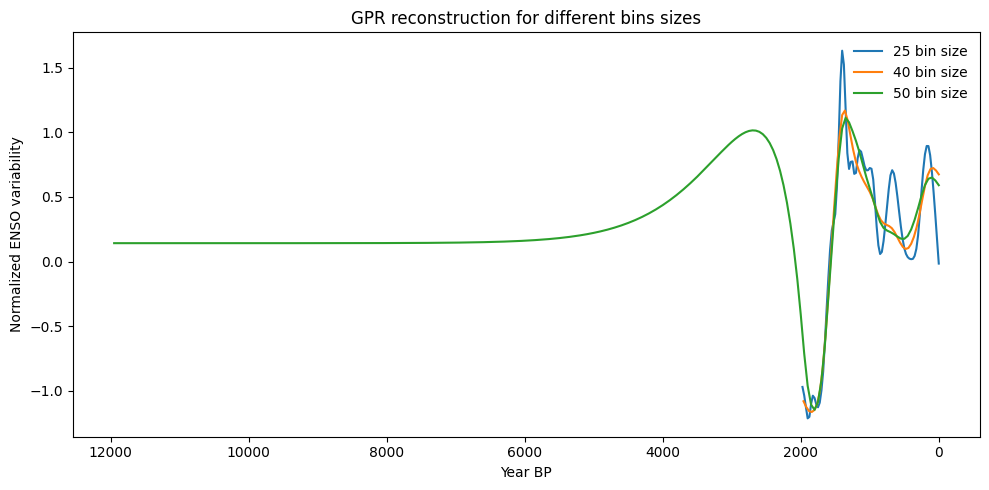

In [27]:
figure_files = glob.glob("saved_binning_reconstructions/binning_reconstruction_*.csv")
print(figure_files)

combined_reconstructions = pd.concat(
    [pd.read_csv(file) for file in figure_files],
    ignore_index=True
)

plt.figure(figsize=(10, 5))

for bins, group in combined_reconstructions.groupby("bins"):
    plt.plot(
        group["year_bp"],
        group["y_pred"],
        label=f"{bins} bin size"
    )
    
plt.gca().invert_xaxis()
plt.xlabel("Year BP")
plt.ylabel("Normalized ENSO variability")
plt.title("GPR reconstruction for different bins sizes")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [28]:
# plotting combined figure
metric_files = glob.glob("saved_binning_reconstructions/metrics_*.csv")

all_metrics = pd.concat(
    [pd.read_csv(file) for file in metric_files],
    ignore_index=True
)

all_metrics = all_metrics.round(3)

all_metrics = all_metrics.sort_values("bins", ascending=False)
print(all_metrics)

all_metrics.to_csv(
    f"saved_binning_reconstructions/fullmetrics.csv",
    index=False
)

   bins  pearson  spearman   rmse  mean_uncertainty
2    50    0.691     0.582  0.860             0.397
1    40    0.516     0.459  0.887             0.328
0    25    0.331     0.248  0.930             0.266
